In [3]:
# input
path2pic = 'reference_images'
path2triplet = 'triplet_dataset'
triplet_dataset = 'triplets_large_final_correctednc_correctedorder.csv'
triplet_index = 'unique_id.txt'
img_extension = '.jpg'

# output
random_index = 'random_index.txt'
triplet_sample_index = 'triplet_sample_index.csv'
# index
triplet_train_index = 'triplet_train_index.csv'
triplet_valid_index = 'triplet_valid_index.csv'
triplet_test_index = 'triplet_test_index.csv'
# CLIP
clip_csv = 'clip.csv'
clip_encoder_index = 'clip_index.npy'
clip_train_csv = 'clip_train.csv'
clip_valid_csv = 'clip_valid.csv'
clip_test_csv = 'clip_test.csv'
# Pixel+PCA
pixel_csv = 'pixel.csv'
pixel_pca_index = 'pixel_index.npy'
pixel_train_csv = 'pixel_train.csv'
pixel_valid_csv = 'pixel_valid.csv'
pixel_test_csv = 'pixel_test.csv'

# Proposal

**Team:** 
- Tangxiaoxue (Katy) Zhang
- Victoria Wen

**Domain:** 
- Cognitive neuroscience & psychology

**Research Background**

- Perceptual similarity has long been treated as foundational to human cognition and concept formation—an intuition that traces back to classical philosophy (e.g., Plato) and continues in modern theories of how categories emerge from experience [(Segundo-Ortin & Hutto, 2021)](https://doi.org/10.1007/s11229-019-02505-1).
- It's widely accepted that similarity judgments are shaped by broad, crossmodal dimensions, yet which dimension dominates under minimal instruction remains an open question [(Di Stefano & Spence, 2024)](https://doi.org/10.1007/s13164-023-00692-y). For example, [Hebart (2020)](https://www.nature.com/articles/s41562-020-00951-3) used a data-driven computational approach to recover a multidimensional structure underlying human similarity judgments, identifying a 49 latent dimensions.
- Recent work in cognitive neuroscience offers an additional lens through **dual-coding** accounts: converging neural and behavioral evidence suggests that knowledge is represented in partially distinct formats—one grounded in sensory/perceptual information and another in more abstract semantic information [(Bi, 2021)](https://doi.org/10.1016/j.tics.2021.07.006). 
- Building on these literatures, our project directly compares semantic and perceptual representations to test which more robustly predicts human “odd-one-out” similarity judgments.

**Research Question:**

In an under-specified grouping task (odd-one-out: “Which image is least similar to the other two?”), do people rely more on semantic similarity or perceptual similarity? Concretely, which representation predicts human odd-one-out choices more robustly: CLIP (semantic space) or Pixel+PCA (perceptual space)?

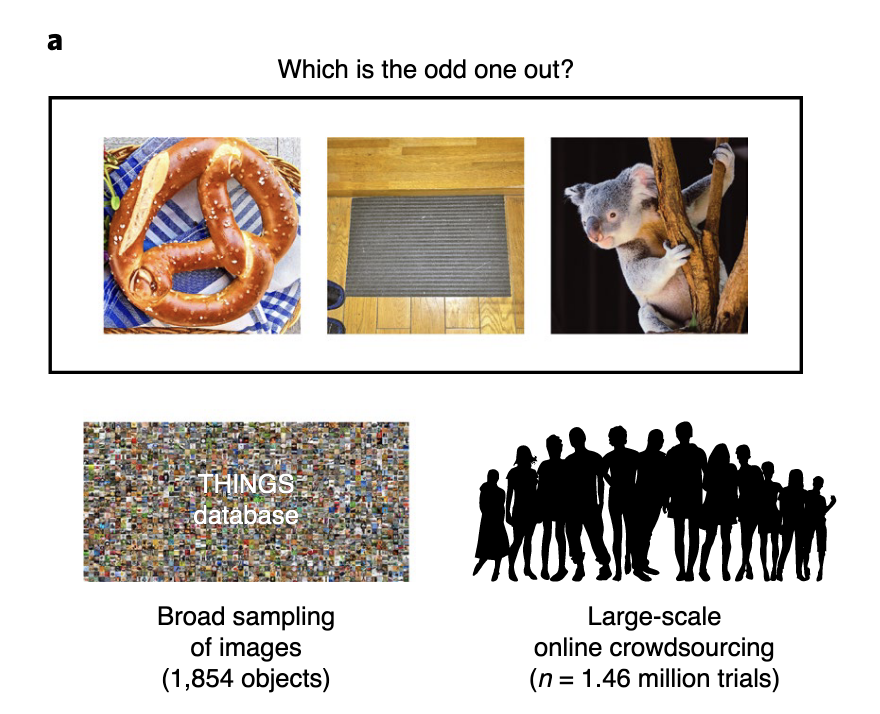

[(Hebart et al., 2020)](https://www.nature.com/articles/s41562-020-00951-3)

**Hypothesis**

Human choices will be better predicted by CLIP embeddings than by pixel-based perceptual embeddings, though pixel similarity may dominate in cases driven by strong low-level visual features (color/shape).

**Data**
-  Human behavior: THINGS odd-one-out dataset (millions of triplet trials). We will sample 50,000 triplets.
- Stimuli: 1,854 THINGS reference images (one per concept).

**Representations**
- Semantic: CLIP image embeddings (512D)
- Perceptual: raw pixel vectors → PCA to 512D (dimension matched to CLIP for fairness)

**ML Task**

3-class classification: given a triplet (A, B, C), predict which item humans choose as the odd-one-out.

**Features (Triplet-level)**

Compute pairwise distances in embedding space: dAB, dAC, dBC (same distance metric for both representations), and encode as one-hot. Use these as the primary features.

In [146]:
import pandas as pd
df_clip = pd.read_csv(clip_csv)
df_clip

,D_0_1,D_0_2,D_0_3,D_1_1,D_1_2,D_1_3,D_2_1,D_2_2,D_2_3,D_3_1,...,D_509_1,D_509_2,D_509_3,D_510_1,D_510_2,D_510_3,D_511_1,D_511_2,D_511_3,Choice
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,3
2,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,3
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
49996,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,3
49997,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2
49998,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,3


In [147]:
df_pixel = pd.read_csv(pixel_csv)
df_pixel

,D_0_1,D_0_2,D_0_3,D_1_1,D_1_2,D_1_3,D_2_1,D_2_2,D_2_3,D_3_1,...,D_509_1,D_509_2,D_509_3,D_510_1,D_510_2,D_510_3,D_511_1,D_511_2,D_511_3,Choice
0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,3
2,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,3
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
49996,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3
49997,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2
49998,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,3


**Models & Evaluation**
- Models: Multinomial logistic regression (L1/L2) + tree-based classifier
- Metrics: Confusion Matrix + ROC
- Error analysis: Model evaluation

**Expected Contribution**

A controlled, quantitative test of whether human “natural” similarity judgments in ambiguous grouping are better captured by semantic vs perceptual representations, with matched dimensionality and interpretable error patterns.

**Further Direction**

Compare those models on:
- Where CLIP wins: semantically coherent clusters (e.g., “fruit vs tools”)
- Where Pixel+PCA wins: strong shared visual features (color/shape/texture)
- Whether failures are driven by certain high-level categories (THINGS categories)

# EDA procedure

## (Data preprocessing) Load and organize data

In [60]:
import os
root_dir = os.path.dirname(os.getcwd())

pic_dir = os.path.join(root_dir, path2pic)
triplet_data = os.path.join(root_dir, path2triplet, triplet_dataset)
triplet_index = os.path.join(root_dir, path2triplet, triplet_index)
random_index = os.path.join(root_dir, path2triplet, random_index)

### Get image name list

In [3]:
with open(triplet_index) as f:
    image_names = [line.strip()+img_extension for line in f.readlines()]
image_names[0:3]

['aardvark.jpg', 'abacus.jpg', 'accordion.jpg']

In [4]:
len(image_names)

1854

In [5]:
picture_path = [os.path.join(pic_dir, image_name) for image_name in image_names]
picture_path[0:5]

['/project/wilma/katyzhang/MACS30100/reference_images/aardvark.jpg',
 '/project/wilma/katyzhang/MACS30100/reference_images/abacus.jpg',
 '/project/wilma/katyzhang/MACS30100/reference_images/accordion.jpg',
 '/project/wilma/katyzhang/MACS30100/reference_images/acorn.jpg',
 '/project/wilma/katyzhang/MACS30100/reference_images/air_conditioner.jpg']

### Get triplet data

#### Original dataset
We would use 4 columns from this dataset:
- image1
- image2
- image3
- choice

In [6]:
import pandas as pd

# read data
triplet = pd.read_csv(triplet_data, sep="\t")
triplet.head(5)

,image1,image2,image3,choice,RT,noise_ceiling,subject_id,HIT_nr,trial_nr,age,gender,date,time,dataset
0,1245,1050,494,3,14457,0,BMWLG5ZY79VLA,1,1,NaN,other,2018-02-05,09:31:16,1
1,888,1788,1250,3,5043,0,BMWLG5ZY79VLA,1,2,NaN,other,2018-02-05,09:31:16,1
2,1256,734,946,2,6605,0,BMWLG5ZY79VLA,1,3,NaN,other,2018-02-05,09:31:16,1
3,1069,1037,953,1,6177,0,BMWLG5ZY79VLA,1,4,NaN,other,2018-02-05,09:31:16,1
4,1693,803,963,3,2327,0,BMWLG5ZY79VLA,1,5,NaN,other,2018-02-05,09:31:16,1


In [69]:
len(triplet)

4699160

##### Original plan: Permutation of a, b, and c
In this project, each sample is defined as a triplet of a, b, and c, representing the items in odd-one-out judgment. They function as positional indices used to distinguish the three slots within a triplet, instead of a new set of stimuli. 
Changing the ordering of samples aims to avoid the model’s learning of positional biases, or treating the position itself as informative. To prevent this, we permute the order of a, b, and c during the data processing and exploratory data analysis. The permutations of the same triplet represent an equivalent set (e.g., (a, b, c), (b, a, c), (c, b, a)) and should yield the same interpretations.

In [ ]:
# from itertools import permutations

# def build_perm_dict():
#     perm_dict = {} # Initailize the dictionary
#     # 6 list, each value represent the original element's position
#     perms = list(permutations([1, 2, 3]))
#     # print(perms)

#     # Loop: each choice
#     for old_choice in [1, 2, 3]:
#         out = []
#         # Loop: through the permutation
#         for p in perms:
#             # value in p represents the original element's position
#             new_choice = p.index(old_choice) + 1 # to avoid the problem of 0 when training the model
#             out.append((p[0], p[1], p[2], new_choice)) # append the data
#         perm_dict[str(old_choice)] = out
#     return perm_dict

# perm_dict = build_perm_dict()
# perm_dict["2"]

[(1, 2, 3, 2),
 (1, 3, 2, 3),
 (2, 1, 3, 1),
 (2, 3, 1, 1),
 (3, 1, 2, 3),
 (3, 2, 1, 2)]

In [ ]:
# import pandas as pd

# def apply_perm_expand(df, perm_dict):
#     rows = []
#     # Loop: for each row in dataframe
#     for _, r in df.iterrows():
#         # only care about 4 columns from the original dataframe
#         r = r[["image1", "image2", "image3", "choice"]]
#         c = str(int(r["choice"]))  # get choice: "1"/"2"/"3"
#         # Loop: through perm_dict
#         for (A_, B_, C_, new_c) in perm_dict[c]:
#             # reorganize
#             old_imgs = [r["image1"], r["image2"], r["image3"]]
#             new_imgs = [old_imgs[A_-1], old_imgs[B_-1], old_imgs[C_-1]]

#             # store in the right order
#             new_r = r.copy()
#             new_r["image1"], new_r["image2"], new_r["image3"] = new_imgs
#             new_r["choice"] = new_c

#             # record the permutation
#             new_r["perm"] = (A_, B_, C_)
#             rows.append(new_r)

#     return pd.DataFrame(rows).reset_index(drop=True)

# triplet_perm = apply_perm_expand(df_train, perm_dict)

In [ ]:
# triplet_perm.to_csv(triplet_train_index, index=False)

In [ ]:
# triplet_perm = pd.read_csv(triplet_train_index)
# print(len(triplet_perm))
# triplet_perm.head(10)

1260000


,image1,image2,image3,choice,perm
0,675,416,1522,1,"(1, 2, 3)"
1,675,1522,416,1,"(1, 3, 2)"
2,416,675,1522,2,"(2, 1, 3)"
3,416,1522,675,3,"(2, 3, 1)"
4,1522,675,416,2,"(3, 1, 2)"
5,1522,416,675,3,"(3, 2, 1)"
6,947,1314,337,2,"(1, 2, 3)"
7,947,337,1314,3,"(1, 3, 2)"
8,1314,947,337,1,"(2, 1, 3)"
9,1314,337,947,1,"(2, 3, 1)"


#### (Error removal) Remove the duplicate from original dataset
There are several within-subject duplicate to check participants' engagement levels, we would directly remove those duplicates

In [7]:
import numpy as np

# remove the duplicate
cols = ["image1", "image2", "image3"]

# create an order-invariant key by sorting the three IDs row-wise
key = pd.DataFrame(np.sort(triplet[cols].to_numpy(), axis=1), columns=[f"k{i}" for i in range(3)])

triplet_unique_any_order = triplet.loc[~key.duplicated()].reset_index(drop=True)
triplet_unique_any_order.head(5)

,image1,image2,image3,choice,RT,noise_ceiling,subject_id,HIT_nr,trial_nr,age,gender,date,time,dataset
0,1245,1050,494,3,14457,0,BMWLG5ZY79VLA,1,1,NaN,other,2018-02-05,09:31:16,1
1,888,1788,1250,3,5043,0,BMWLG5ZY79VLA,1,2,NaN,other,2018-02-05,09:31:16,1
2,1256,734,946,2,6605,0,BMWLG5ZY79VLA,1,3,NaN,other,2018-02-05,09:31:16,1
3,1069,1037,953,1,6177,0,BMWLG5ZY79VLA,1,4,NaN,other,2018-02-05,09:31:16,1
4,1693,803,963,3,2327,0,BMWLG5ZY79VLA,1,5,NaN,other,2018-02-05,09:31:16,1


In [8]:
len(triplet_unique_any_order)

4567526

#### (Distribution Check) Extract random sample from whole dataset
Randomly select 50,000 data, cause the dataset is too large: 469,9160

In [9]:
sample_n = 50000

In [10]:
# set tag to detect: (1) all images included? (2) contain duplicates? (3) balanced distribution?
all_images_included_tag = 0
no_duplicate_tag = 0
distribution_tag = 0

In [ ]:
# # Randomly select 50,000 data, cause the dataset is too large: 469,9160
# i = 0
# while not (all_images_included_tag and no_duplicate_tag and distribution_tag):
#     # Tag how many times of trying
#     i += 1
#     print("--"*5, f"try {i}: ", "--"*5)

#     random_index_label = triplet_unique_any_order.sample(n=sample_n).index
#     # to make sure that all the images are included
#     image_set = set() 
#     # detect duplicate
#     duplicate_detect_set = set()
#     for index in random_index_label:
#         img1 = triplet_unique_any_order["image1"].iloc[index]
#         img2 = triplet_unique_any_order["image2"].iloc[index]
#         img3 = triplet_unique_any_order["image3"].iloc[index]
#         image_set.add(img1)
#         image_set.add(img2)
#         image_set.add(img3)
#         duplicate_detect_set.add((img1, img2, img3))

#     print(random_index_label.unique())

#     all_images_included_tag = (len(image_set)==len(image_names))
#     print("All images (1854) are included in the sample:", all_images_included_tag)

#     no_duplicate_tag = (len(duplicate_detect_set)==len(random_index_label))
#     print("No duplicate images combinations in the sample:", no_duplicate_tag)

#     # if index is valid, then check the distribution
#     if all_images_included_tag and no_duplicate_tag:
#         triplet_sample = triplet_unique_any_order[["image1", "image2", "image3", "choice"]].iloc[random_index_label]
#         distribution_tag = (triplet_sample['choice'].value_counts()/sample_n> 0.32999).all()
#         print("Balanced distribution:", distribution_tag)

---------- try 1:  ----------
Index([2286584, 1816818, 3246105, 4094636, 4484500, 1333339, 4559183, 2527085,
        663272, 2237497,
       ...
       2811376, 4060886,  735013, 4538406, 2763277, 2235415, 3166665, 3701074,
       1662620, 1643074],
      dtype='int64', length=50000)
All images (1854) are included in the sample: True
No duplicate images combinations in the sample: True
Balanced distribution: False
---------- try 2:  ----------
Index([2771743,  807546, 4291790, 3809548, 2336926,  890943, 2448228,  522981,
       1326233, 2882549,
       ...
        755531,   20405, 3667735, 1420652, 2200994, 2981171, 4290830, 2981578,
       3792089, 2885047],
      dtype='int64', length=50000)
All images (1854) are included in the sample: True
No duplicate images combinations in the sample: True
Balanced distribution: False
---------- try 3:  ----------
Index([4208858, 3804838,  305699, 3931447, 1798471,  540489, 2503892, 1851074,
       3981925, 2514954,
       ...
       3967748, 418

In [ ]:
# with open(random_index, mode = "w") as f:
#     for index in random_index_label:
#         f.write(str(index) + '\n')

In [13]:
with open(random_index) as f:
    index_selected = [line.strip() for line in f.readlines()]
    
len(index_selected)

50000

In [ ]:
# triplet_sample = triplet_unique_any_order[["image1", "image2", "image3", "choice"]].iloc[index_selected]
# triplet_sample.to_csv(triplet_sample_index, index=False)

In [20]:
triplet_sample = pd.read_csv(triplet_sample_index)

In [21]:
triplet_sample['choice'].value_counts()

choice
2    16900
1    16561
3    16539
Name: count, dtype: int64

In [22]:
triplet_sample.head(5)

,image1,image2,image3,choice
0,731,1152,1225,3
1,1498,1790,152,3
2,899,1737,834,1
3,1167,793,1309,1
4,720,1843,753,3


### Original plan: split data into 3 sets
- 70% for training set
- 15% for validation set
- 15% for testing set

In [23]:
ratio_train = 0.7
ratio_test = 0.15

ratio_valid = 1 - ratio_train - ratio_test
ratio_ttsplit = ratio_test
ratio_tvsplit = ratio_valid / (ratio_train + ratio_valid)

In [24]:
from sklearn.model_selection import train_test_split

triplet_sample_X = triplet_sample[["image1", "image2", "image3"]]
triplet_sample_y = triplet_sample["choice"]
X_main, X_test, y_main, y_test = train_test_split(triplet_sample_X, triplet_sample_y, test_size=ratio_ttsplit, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_main, y_main, test_size=ratio_tvsplit, random_state=42)
df_train = X_train.join(y_train)
df_valid = X_val.join(y_val)
df_test = X_test.join(y_test)

In [ ]:
# df_train.to_csv(triplet_train_index, index=False)
# df_valid.to_csv(triplet_valid_index, index=False)
# df_test.to_csv(triplet_test_index, index=False)

## (Data transformation) Feature generation

### Convert pictures using CLIP encoder
Using [CLIP](https://openai.com/index/clip/) to convert one image into a vector (512, 1) to represent this image's positions in CLIP "semantic space".
- In other word, embedding the pictures using the semantic information

In [87]:
import clip
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load(
    "ViT-B/32",
    device=device,
    download_root="/project/wilma/katyzhang/CLIP"
)
model.eval()

CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(32, 32), stride=(32, 32), bias=False)
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): Sequential(
        (0): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
        (1): ResidualAttentionBlock(
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          

In [88]:
import PIL.Image as Image
import json

def encode_image_openclip(image_paths, device=device, dtype=np.float32):
    N = len(image_paths)
    X = np.zeros((N, 512), dtype=dtype)

    for i, p in enumerate(image_paths):
        image = Image.open(p).convert("RGB")
        
        image_tensor = preprocess(image).unsqueeze(0).to(device)
        with torch.no_grad():
            image_features = model.encode_image(image_tensor)
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)

        if (i + 1) % 200 == 0:
            print(f"Loaded {i+1}/{N}")

        X[i] = image_features
    
    return X

clip_index = encode_image_openclip(picture_path)
print("")
print("clip_index:", clip_index.shape)

Loaded 200/1854
Loaded 400/1854
Loaded 600/1854
Loaded 800/1854
Loaded 1000/1854
Loaded 1200/1854
Loaded 1400/1854
Loaded 1600/1854
Loaded 1800/1854

clip_index: (1854, 512)


In [67]:
# np.save(clip_encoder_index, clip_index)
pixel_pca_index = np.load(pixel_pca_index)

In [68]:
pixel_pca_index

array([[-2.81940126e+00, -7.92399073e+00,  1.29270840e+01, ...,
        -4.71106857e-01,  3.19200873e-01,  1.63189170e-03],
       [-1.53982677e+01,  5.77915192e+00, -3.30095935e+00, ...,
         6.23842597e-01, -3.83616775e-01, -2.02913389e-01],
       [-1.00450201e+01, -7.94576824e-01,  3.46603966e+00, ...,
         2.20978484e-01,  1.29831582e-01,  2.75903761e-01],
       ...,
       [-1.39530306e+01, -8.22804737e+00,  9.32325077e+00, ...,
        -1.02205217e-01, -9.98653099e-02, -8.97972845e-03],
       [-1.70380611e+01, -1.68680191e+00, -9.02618313e+00, ...,
        -9.15905237e-02, -1.01371594e-01, -5.08287489e-01],
       [-2.25513859e+01,  4.62803507e+00,  3.02098781e-01, ...,
         1.14485115e-01, -3.67966503e-01, -1.90299094e-01]],
      shape=(1854, 512), dtype=float32)

### Convert pictures into pixels
To match the output dimension of CLIP (512, 1), we use PCA (dimention = 512) to capture the picture's pixel level charateristics. To avoid memory issue, we would resize the pictures into (64, 64, 3)
- In other word, embedding the pictures using the perceptual information

In [89]:
import json
import numpy as np
from PIL import Image
from sklearn.decomposition import PCA

def load_pixels_matrix(image_paths, size=(64, 64), dtype=np.float32):
    """
    resize the pictures into (64, 64,3)
    """
    N = len(image_paths)
    D = size[0] * size[1] * 3
    X = np.zeros((N, D), dtype=dtype)

    for i, p in enumerate(image_paths):
        img = Image.open(p).convert("RGB").resize(size, Image.BICUBIC)
        arr = np.asarray(img, dtype=np.uint8)               # (64,64,3)
        X[i] = (arr.reshape(-1).astype(dtype) / 255.0)      # (12288,)

        if (i + 1) % 200 == 0:
            print(f"Loaded {i+1}/{N}")

    return X

# ---- usage ----
# image_paths = [...]  # list of 1854 file paths

X = load_pixels_matrix(picture_path, size=(64, 64))

pca = PCA(n_components=512, random_state=0)
pixel_index = pca.fit_transform(X)   # (N,512)

print("")
print("X:", X.shape, "pixel_index:", pixel_index.shape)

Loaded 200/1854
Loaded 400/1854
Loaded 600/1854
Loaded 800/1854
Loaded 1000/1854
Loaded 1200/1854
Loaded 1400/1854
Loaded 1600/1854
Loaded 1800/1854

X: (1854, 12288) pixel_index: (1854, 512)


In [ ]:
# np.save(pixel_pca_index, pixel_index)

## Build up the dataset

- For each feature(dimension), the absolute distance will be calculated among 3 pictures, to get the most dissimilar picture.
- That picture's order would be seen as the input for that feature.

In [42]:
# read df_train, df_valid, df_test
import pandas as pd

df_train = pd.read_csv(triplet_train_index)
df_valid = pd.read_csv(triplet_valid_index)
df_test = pd.read_csv(triplet_test_index)

### (Semantic dataset) CLIP
- feature(512): Dimention
- row: each "odd-one-out" task

In [43]:
import pandas as pd
import numpy as np

def farthest_idx(X):
    """
    X: array-like, shape (N,3)
    returns:
      idx_1based: shape (N,) values in {1,2,3}
      farthest_val: shape (N,)
    """
    X = np.asarray(X).T

    d01 = np.abs(X[:, 0] - X[:, 1])
    d02 = np.abs(X[:, 0] - X[:, 2])
    d12 = np.abs(X[:, 1] - X[:, 2])

    scores = np.stack([
        d01 + d02,  # element 1 vs others
        d01 + d12,  # element 2 vs others
        d02 + d12   # element 3 vs others
    ], axis=1)  # (N,3)

    idx0 = np.argmax(scores, axis=1)              # (N,) 0-based
    idx_1based = idx0 + 1                         # (N,) in {1,2,3}
    return idx_1based

clip_encoder = np.load(clip_encoder_index)
dimension = len(clip_encoder[0])

In [ ]:
# clip_train
column_names = [f"D_{i}" for i in range(dimension)] + ["Choice"]
clip_train = pd.DataFrame(columns=column_names)
train_len = len(df_train)

ii = 0
for index, row in df_train.iterrows():
    # get clip vectors for each image
    clip_img1 = clip_encoder[row['image1']-1]
    clip_img2 = clip_encoder[row['image2']-1]
    clip_img3 = clip_encoder[row['image3']-1]
    # calculate the most dissimilar piture for each dimention
    idx = farthest_idx([clip_img1, clip_img2, clip_img3])
    organized_row = np.append(idx, row['choice'])
    # update the dataframe (clip_train)
    clip_train.loc[ii] = organized_row
    ii += 1
    if not ii % 5000:
        print(f"having finished: {ii}/{train_len}")

clip_train.to_csv(clip_train_csv, index=False)
clip_train

having finished: 5000/34999
having finished: 10000/34999
having finished: 15000/34999
having finished: 20000/34999
having finished: 25000/34999
having finished: 30000/34999


,D_0,D_1,D_2,D_3,D_4,D_5,D_6,D_7,D_8,D_9,...,D_503,D_504,D_505,D_506,D_507,D_508,D_509,D_510,D_511,Choice
0,2,2,3,1,3,3,3,3,3,2,...,1,2,1,3,1,2,1,3,1,3
1,2,1,3,2,3,2,3,3,2,1,...,1,2,1,1,1,3,1,2,3,3
2,2,3,1,3,3,2,1,1,3,2,...,2,2,1,2,2,3,1,3,2,3
3,3,3,2,2,2,3,1,3,3,3,...,2,3,2,2,3,3,2,3,1,3
4,2,3,3,1,1,2,1,3,3,2,...,2,1,2,1,1,1,2,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34994,3,1,2,3,3,2,3,2,2,1,...,3,3,1,1,3,2,1,1,1,1
34995,2,2,3,1,1,1,2,2,1,3,...,3,2,3,2,2,2,3,2,1,1
34996,2,1,2,2,2,2,2,1,3,1,...,1,2,1,2,1,1,1,3,1,1
34997,3,2,2,2,2,1,2,3,1,3,...,2,3,2,2,2,2,1,2,1,1


In [ ]:
# clip_valid
column_names = [f"D_{i}" for i in range(dimension)] + ["Choice"]
clip_valid = pd.DataFrame(columns=column_names)
valid_len = len(df_valid)

ii = 0
for index, row in df_valid.iterrows():
    # get clip vectors for each image
    clip_img1 = clip_encoder[row['image1']-1]
    clip_img2 = clip_encoder[row['image2']-1]
    clip_img3 = clip_encoder[row['image3']-1]
    # calculate the most dissimilar piture for each dimention
    idx = farthest_idx([clip_img1, clip_img2, clip_img3])
    organized_row = np.append(idx, row['choice'])
    # update the dataframe (clip_valid)
    clip_valid.loc[ii] = organized_row
    ii += 1
    if not ii % 5000:
        print(f"having finished: {ii}/{valid_len}")

clip_valid.to_csv(clip_valid_csv, index=False)
clip_valid

having finished: 5000/7501


,D_0,D_1,D_2,D_3,D_4,D_5,D_6,D_7,D_8,D_9,...,D_503,D_504,D_505,D_506,D_507,D_508,D_509,D_510,D_511,Choice
0,2,2,1,3,3,2,2,3,1,3,...,3,1,1,3,2,3,3,3,3,3
1,3,3,1,1,1,2,2,1,3,1,...,1,3,1,3,3,3,3,2,1,3
2,2,2,2,2,1,1,2,2,3,3,...,3,2,2,3,1,3,3,3,3,3
3,3,1,1,1,2,1,2,2,1,3,...,3,3,1,3,3,2,3,3,3,1
4,3,1,1,2,3,2,1,1,3,1,...,2,2,2,3,3,2,1,3,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,3,3,1,1,1,1,1,3,3,1,...,3,3,3,3,2,2,3,2,1,3
7497,1,2,3,3,1,1,2,1,2,3,...,2,1,1,3,3,2,2,3,1,3
7498,3,1,1,3,1,3,3,2,2,1,...,3,2,1,3,3,2,1,2,1,1
7499,3,2,1,1,2,1,1,1,2,3,...,3,3,1,1,2,1,2,3,2,2


In [ ]:
# clip_test
column_names = [f"D_{i}" for i in range(dimension)] + ["Choice"]
clip_test = pd.DataFrame(columns=column_names)
test_len = len(df_test)

ii = 0
for index, row in df_test.iterrows():
    # get clip vectors for each image
    clip_img1 = clip_encoder[row['image1']-1]
    clip_img2 = clip_encoder[row['image2']-1]
    clip_img3 = clip_encoder[row['image3']-1]
    # calculate the most dissimilar piture for each dimention
    idx = farthest_idx([clip_img1, clip_img2, clip_img3])
    organized_row = np.append(idx, row['choice'])
    # update the dataframe (clip_test)
    clip_test.loc[ii] = organized_row
    ii += 1
    if not ii % 5000:
        print(f"having finished: {ii}/{test_len}")

clip_test.to_csv(clip_test_csv, index=False)
clip_test

having finished: 5000/7500


,D_0,D_1,D_2,D_3,D_4,D_5,D_6,D_7,D_8,D_9,...,D_503,D_504,D_505,D_506,D_507,D_508,D_509,D_510,D_511,Choice
0,2,2,1,3,2,1,1,2,3,2,...,3,2,2,1,2,3,3,1,3,3
1,3,3,1,2,3,3,3,3,2,1,...,2,3,1,2,3,3,2,3,3,3
2,2,1,2,1,3,3,2,3,3,1,...,1,2,3,1,2,2,3,1,2,1
3,3,3,3,3,2,3,1,3,2,3,...,1,2,3,1,1,3,2,2,2,1
4,3,2,2,1,3,2,3,1,1,1,...,2,3,2,3,1,3,2,1,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,2,2,2,2,1,2,1,1,1,2,...,1,2,2,2,2,2,2,2,1,1
7496,3,3,2,1,3,3,3,3,3,2,...,1,2,2,2,3,1,1,2,3,3
7497,2,1,1,3,1,3,2,1,2,2,...,1,3,1,2,2,1,1,1,2,2
7498,2,3,2,3,2,2,1,2,2,3,...,2,1,3,1,2,2,2,2,1,3


In [35]:
df_clip = pd.concat([clip_train, clip_valid, clip_test])
df_clip

,D_0,D_1,D_2,D_3,D_4,D_5,D_6,D_7,D_8,D_9,...,D_503,D_504,D_505,D_506,D_507,D_508,D_509,D_510,D_511,Choice
0,2,2,3,1,3,3,3,3,3,2,...,1,2,1,3,1,2,1,3,1,3
1,2,1,3,2,3,2,3,3,2,1,...,1,2,1,1,1,3,1,2,3,3
2,2,3,1,3,3,2,1,1,3,2,...,2,2,1,2,2,3,1,3,2,3
3,3,3,2,2,2,3,1,3,3,3,...,2,3,2,2,3,3,2,3,1,3
4,2,3,3,1,1,2,1,3,3,2,...,2,1,2,1,1,1,2,3,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,2,2,2,2,1,2,1,1,1,2,...,1,2,2,2,2,2,2,2,1,1
7496,3,3,2,1,3,3,3,3,3,2,...,1,2,2,2,3,1,1,2,3,3
7497,2,1,1,3,1,3,2,1,2,2,...,1,3,1,2,2,1,1,1,2,2
7498,2,3,2,3,2,2,1,2,2,3,...,2,1,3,1,2,2,2,2,1,3


### (Perceptual dataset) Pixel+PCA

In [47]:
import pandas as pd
import numpy as np

def farthest_idx(X):
    """
    X: array-like, shape (N,3)
    returns:
      idx_1based: shape (N,) values in {1,2,3}
      farthest_val: shape (N,)
    """
    X = np.asarray(X).T

    d01 = np.abs(X[:, 0] - X[:, 1])
    d02 = np.abs(X[:, 0] - X[:, 2])
    d12 = np.abs(X[:, 1] - X[:, 2])

    scores = np.stack([
        d01 + d02,  # element 1 vs others
        d01 + d12,  # element 2 vs others
        d02 + d12   # element 3 vs others
    ], axis=1)  # (N,3)

    idx0 = np.argmax(scores, axis=1)              # (N,) 0-based
    idx_1based = idx0 + 1                         # (N,) in {1,2,3}
    return idx_1based

pixel_encoder = np.load(pixel_pca_index)
dimension = len(pixel_encoder[0])

In [48]:
# pixel_train
column_names = [f"D_{i}" for i in range(dimension)] + ["Choice"]
pixel_train = pd.DataFrame(columns=column_names)
train_len = len(df_train)

ii = 0
for index, row in df_train.iterrows():
    # get pixel vectors for each image
    pixel_img1 = pixel_encoder[row['image1']-1]
    pixel_img2 = pixel_encoder[row['image2']-1]
    pixel_img3 = pixel_encoder[row['image3']-1]
    # calculate the most dissimilar piture for each dimention
    idx = farthest_idx([pixel_img1, pixel_img2, pixel_img3])
    organized_row = np.append(idx, row['choice'])
    # update the dataframe (pixel_train)
    pixel_train.loc[ii] = organized_row
    ii += 1
    if not ii % 5000:
        print(f"having finished: {ii}/{train_len}")

pixel_train.to_csv(pixel_train_csv, index=False)
pixel_train

having finished: 5000/34999
having finished: 10000/34999
having finished: 15000/34999
having finished: 20000/34999
having finished: 25000/34999
having finished: 30000/34999


,D_0,D_1,D_2,D_3,D_4,D_5,D_6,D_7,D_8,D_9,...,D_503,D_504,D_505,D_506,D_507,D_508,D_509,D_510,D_511,Choice
0,3,1,3,2,2,1,3,1,1,3,...,3,3,2,2,2,2,1,3,1,3
1,2,1,3,1,2,1,2,2,2,2,...,1,3,2,2,2,1,3,1,3,3
2,3,2,1,1,3,1,2,2,1,2,...,1,1,2,1,2,1,2,1,1,3
3,1,3,1,1,3,3,3,3,2,3,...,2,3,3,1,1,2,3,1,2,3
4,3,3,3,3,1,2,3,3,1,1,...,2,2,1,3,1,2,3,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34994,2,1,3,2,3,1,3,2,3,1,...,2,2,2,1,2,2,3,2,2,1
34995,2,1,1,3,3,1,3,1,2,3,...,2,2,2,1,2,3,2,2,1,1
34996,2,2,2,3,2,1,3,2,2,1,...,3,3,1,2,3,2,1,2,1,1
34997,3,3,1,2,3,2,2,3,2,1,...,3,2,3,1,2,2,1,3,1,1


In [49]:
# pixel_valid
column_names = [f"D_{i}" for i in range(dimension)] + ["Choice"]
pixel_valid = pd.DataFrame(columns=column_names)
valid_len = len(df_valid)

ii = 0
for index, row in df_valid.iterrows():
    # get pixel vectors for each image
    pixel_img1 = pixel_encoder[row['image1']-1]
    pixel_img2 = pixel_encoder[row['image2']-1]
    pixel_img3 = pixel_encoder[row['image3']-1]
    # calculate the most dissimilar piture for each dimention
    idx = farthest_idx([pixel_img1, pixel_img2, pixel_img3])
    organized_row = np.append(idx, row['choice'])
    # update the dataframe (pixel_valid)
    pixel_valid.loc[ii] = organized_row
    ii += 1
    if not ii % 5000:
        print(f"having finished: {ii}/{valid_len}")

pixel_valid.to_csv(pixel_valid_csv, index=False)
pixel_valid

having finished: 5000/7501


,D_0,D_1,D_2,D_3,D_4,D_5,D_6,D_7,D_8,D_9,...,D_503,D_504,D_505,D_506,D_507,D_508,D_509,D_510,D_511,Choice
0,1,2,2,2,1,2,2,1,3,1,...,2,3,2,1,1,2,2,1,3,3
1,3,3,2,1,1,3,3,3,3,2,...,3,2,2,3,2,3,3,1,1,3
2,2,1,1,3,2,3,3,1,3,3,...,3,1,1,3,3,1,2,3,1,3
3,3,3,2,1,1,1,1,3,2,2,...,3,3,1,2,1,2,3,1,1,1
4,2,2,2,3,2,2,3,3,3,3,...,2,1,1,2,3,3,3,1,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,2,3,3,3,1,1,3,1,3,1,...,3,3,3,3,3,1,3,3,3,3
7497,1,3,1,1,1,1,1,1,2,3,...,1,1,1,1,2,2,1,1,2,3
7498,1,1,3,2,2,1,3,2,3,1,...,2,2,3,3,2,1,3,2,2,1
7499,2,1,1,3,3,2,2,3,2,3,...,2,1,1,3,1,2,3,3,3,2


In [50]:
# pixel_test
column_names = [f"D_{i}" for i in range(dimension)] + ["Choice"]
pixel_test = pd.DataFrame(columns=column_names)
test_len = len(df_test)

ii = 0
for index, row in df_test.iterrows():
    # get pixel vectors for each image
    pixel_img1 = pixel_encoder[row['image1']-1]
    pixel_img2 = pixel_encoder[row['image2']-1]
    pixel_img3 = pixel_encoder[row['image3']-1]
    # calculate the most dissimilar piture for each dimention
    idx = farthest_idx([pixel_img1, pixel_img2, pixel_img3])
    organized_row = np.append(idx, row['choice'])
    # update the dataframe (pixel_test)
    pixel_test.loc[ii] = organized_row
    ii += 1
    if not ii % 5000:
        print(f"having finished: {ii}/{test_len}")

pixel_test.to_csv(pixel_test_csv, index=False)
pixel_test

having finished: 5000/7500


,D_0,D_1,D_2,D_3,D_4,D_5,D_6,D_7,D_8,D_9,...,D_503,D_504,D_505,D_506,D_507,D_508,D_509,D_510,D_511,Choice
0,1,2,3,2,2,2,1,1,2,1,...,1,2,2,3,3,1,2,2,3,3
1,1,3,2,2,2,3,2,1,1,2,...,3,1,3,1,1,1,3,3,1,3
2,3,3,1,1,1,2,3,3,1,1,...,1,1,1,3,1,1,3,1,3,1
3,3,1,1,1,1,3,2,2,1,2,...,3,1,3,1,3,1,3,1,2,1
4,2,1,2,2,1,3,3,3,1,2,...,3,3,2,3,3,3,3,3,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,3,1,3,3,2,1,2,3,2,1,...,2,2,3,2,1,2,1,2,1,1
7496,2,2,1,3,3,2,2,3,2,3,...,1,3,3,1,3,3,2,2,2,3
7497,2,2,3,3,1,3,2,3,2,3,...,3,2,2,2,3,2,2,3,1,2
7498,3,1,1,1,3,3,3,3,2,2,...,2,2,1,1,1,2,3,1,2,3


In [36]:
df_pixel = pd.concat([pixel_train, pixel_valid, pixel_test])
df_pixel

,D_0,D_1,D_2,D_3,D_4,D_5,D_6,D_7,D_8,D_9,...,D_503,D_504,D_505,D_506,D_507,D_508,D_509,D_510,D_511,Choice
0,3,1,3,2,2,1,3,1,1,3,...,3,3,2,2,2,2,1,3,1,3
1,2,1,3,1,2,1,2,2,2,2,...,1,3,2,2,2,1,3,1,3,3
2,3,2,1,1,3,1,2,2,1,2,...,1,1,2,1,2,1,2,1,1,3
3,1,3,1,1,3,3,3,3,2,3,...,2,3,3,1,1,2,3,1,2,3
4,3,3,3,3,1,2,3,3,1,1,...,2,2,1,3,1,2,3,2,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,3,1,3,3,2,1,2,3,2,1,...,2,2,3,2,1,2,1,2,1,1
7496,2,2,1,3,3,2,2,3,2,3,...,1,3,3,1,3,3,2,2,2,3
7497,2,2,3,3,1,3,2,3,2,3,...,3,2,2,2,3,2,2,3,1,2
7498,3,1,1,1,3,3,3,3,2,2,...,2,2,1,1,1,2,3,1,2,3


In [ ]:
# clip_train.to_csv(clip_train_csv, index=False)
# clip_valid.to_csv(clip_valid_csv, index=False)
# clip_test.to_csv(clip_test_csv, index=False)
# pixel_train.to_csv(pixel_train_csv, index=False)
# pixel_valid.to_csv(pixel_valid_csv, index=False)
# pixel_test.to_csv(pixel_test_csv, index=False)

## (One-Hot Encoder) Encode the features
Each Feature represents the labels got from the current dimesion, {"1", "2", "3"}, so need to use the one-hot encoder to conver the features into 0-1

In [ ]:
X_clip = df_clip.copy().drop("Choice", axis=1).astype(str)
y_clip = df_clip["Choice"].astype(str)

In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# get columns
X_cols = X_clip.columns
# one_hot_encoder
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False) 
X_ohe = ohe.fit_transform(X_clip[X_cols])
# feature names
feat_names = ohe.get_feature_names_out(X_cols)
# new dataframe
X_ohe_df = pd.DataFrame(X_ohe, columns=feat_names, index=X_clip.index)
# concatenate
X_clip_full = pd.concat([X_ohe_df, y_clip], axis=1)

X_clip_full.to_csv(clip_csv, index=False)
X_clip_full

,D_0_1,D_0_2,D_0_3,D_1_1,D_1_2,D_1_3,D_2_1,D_2_2,D_2_3,D_3_1,...,D_509_1,D_509_2,D_509_3,D_510_1,D_510_2,D_510_3,D_511_1,D_511_2,D_511_3,Choice
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,3
2,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,3
3,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3
4,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
7496,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,3
7497,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,2
7498,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,3


In [49]:
X_pixel = df_pixel.copy().drop("Choice", axis=1).astype(str)
y_pixel = df_pixel["Choice"].astype(str)

In [50]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# get columns
X_cols = X_pixel.columns
# one_hot_encoder
ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False) 
X_ohe = ohe.fit_transform(X_pixel[X_cols])
# feature names
feat_names = ohe.get_feature_names_out(X_cols)
# new dataframe
X_ohe_df = pd.DataFrame(X_ohe, columns=feat_names, index=X_pixel.index)
# concatenate
X_pixel_full = pd.concat([X_ohe_df, y_pixel], axis=1)

X_pixel_full.to_csv(pixel_csv, index=False)
X_pixel_full

,D_0_1,D_0_2,D_0_3,D_1_1,D_1_2,D_1_3,D_2_1,D_2_2,D_2_3,D_3_1,...,D_509_1,D_509_2,D_509_3,D_510_1,D_510_2,D_510_3,D_511_1,D_511_2,D_511_3,Choice
0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3
1,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,3
2,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,3
3,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,3
4,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1
7496,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,3
7497,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,2
7498,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,3


# Decision Tree
Overall, based on Decision Tree model, CLIP behaves better than Pixel, which aligns with previous hypothesis:
- The test accuracy for CLIP (DT): 0.3704
- The test accuracy for Pixel (DT): 0.3321
- The test accuracy for Pixel (RF): 0.3618

The Decision Tree model's performance for Pixel_Dataset is not above the random level, so I further run the Random Forest model for that dataset. It turns out that the random Forest is better the Decision Tree:
- The test accuracy for Best Decision Tree Model: 0.3321
- The test accuracy for Best Random Forest Model: 0.3618

## Using Decision Tree

### CLIP

#### Training model and Tuning the hyperparameters

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_clip = pd.read_csv(clip_csv)

In [5]:
X_clip = df_clip.copy().drop("Choice", axis=1)
y_clip = df_clip["Choice"].astype(str)

In [ ]:
X_clip_train, X_clip_test, y_clip_train, y_clip_test = train_test_split(
    X_clip, y_clip, 
    test_size=0.2, 
    random_state=0)

In [9]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=0)

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [10, 15, 20],
    "min_samples_split": [10, 15, 20],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt", "log2"],
    "ccp_alpha": [1e-4, 1e-3, 1e-2],
}

gs_clip = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="accuracy",
    cv=2,
    verbose=1, # basic output-1; detailed output-2
    return_train_score=True
)

gs_clip.fit(X_clip_train, y_clip_train)

best_model = gs_clip.best_estimator_
test_acc = best_model.score(X_clip_test, y_clip_test)

print("Best CV score (train CV):", gs_clip.best_score_)
print("Test accuracy:", test_acc)

Fitting 2 folds for each of 324 candidates, totalling 648 fits
Best CV score (train CV): 0.386075
Test accuracy: 0.3704


In [10]:
gs_clip

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0.0001, 0.001, ...], 'criterion': ['gini', 'entropy'], 'max_depth': [10, 15, ...], 'max_features': ['sqrt', 'log2'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",2
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for ea

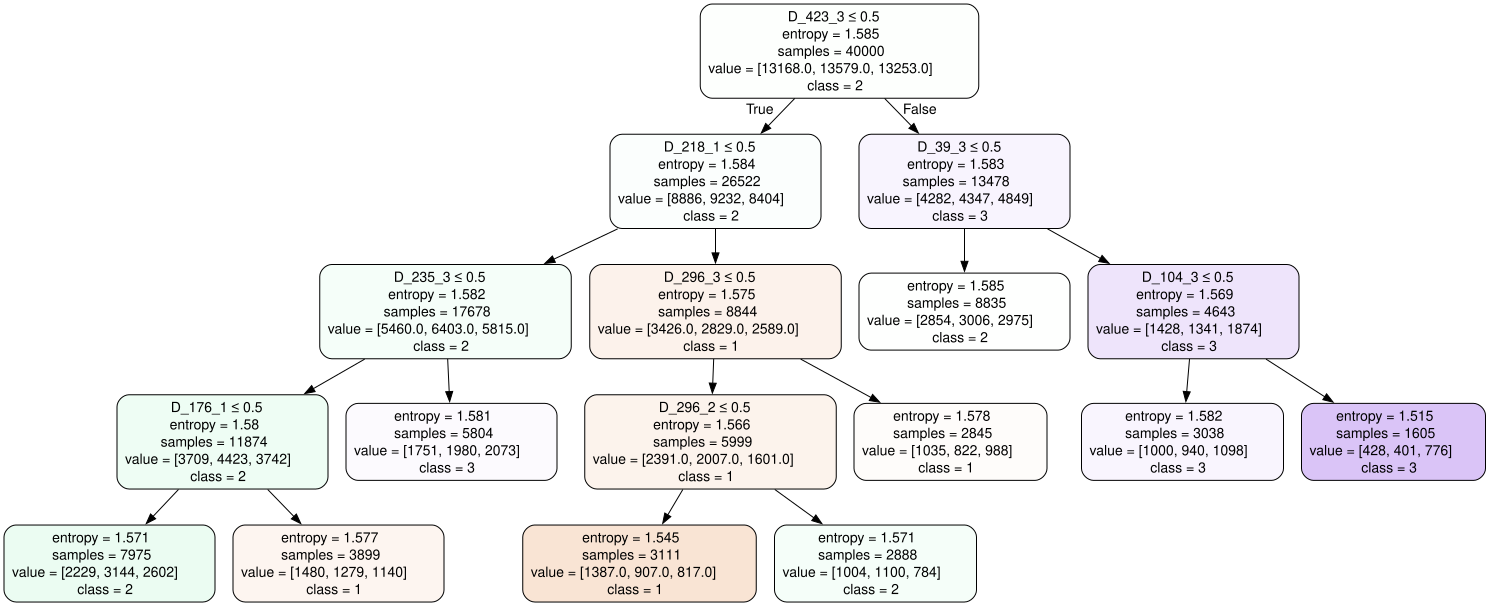

In [11]:
from sklearn import tree
import graphviz

dt_clip = gs_clip.best_estimator_

feature_names = list(X_clip.columns)
target_names = [str(c) for c in dt_clip.classes_]  # class labels as strings

dot_data = tree.export_graphviz(
    dt_clip,
    out_file=None,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    special_characters=True,
)

graph = graphviz.Source(dot_data)
graph

In [32]:
# check and interpret feature importance
dt_clip = gs_clip.best_estimator_

importances = dt_clip.feature_importances_
feat_names = X_clip.columns if hasattr(X_clip, "columns") else [f"f{i}" for i in range(X_clip.shape[1])]

fi = (pd.DataFrame({"feature": feat_names, "importance": importances})
        .sort_values("importance", ascending=False))

print("Non-zero features used:", (fi["importance"] > 0).sum())
fi.head(10)

Non-zero features used: 8


,feature,importance
654,D_218_1,0.247005
528,D_176_1,0.187421
1271,D_423_3,0.114057
889,D_296_2,0.111064
119,D_39_3,0.099275
314,D_104_3,0.098825
890,D_296_3,0.092207
707,D_235_3,0.050145
1030,D_343_2,0.000000
1029,D_343_1,0.000000


#### Error Analysis

##### Confusion Matrix
Overall, the model is more likely to predict the label as "2"

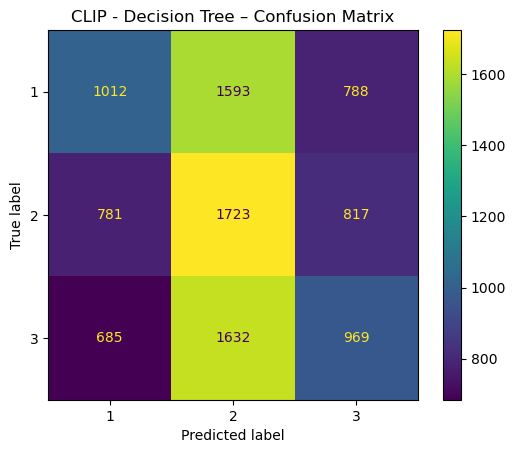

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

# predictions
y_pred = dt_clip.predict(X_clip_test)

# confusion matrix
cm = confusion_matrix(y_clip_test, y_pred, labels=dt_clip.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_clip.classes_)
disp.plot(values_format="d")
plt.title("CLIP - Decision Tree – Confusion Matrix")
plt.show()

In [18]:
import numpy as np
print(classification_report(y_clip_test, y_pred,zero_division=np.nan))

              precision    recall  f1-score   support

           1       0.41      0.30      0.34      3393
           2       0.35      0.52      0.42      3321
           3       0.38      0.29      0.33      3286

    accuracy                           0.37     10000
   macro avg       0.38      0.37      0.36     10000
weighted avg       0.38      0.37      0.36     10000



##### ROC
This Decision Tree model's performance is above the random level

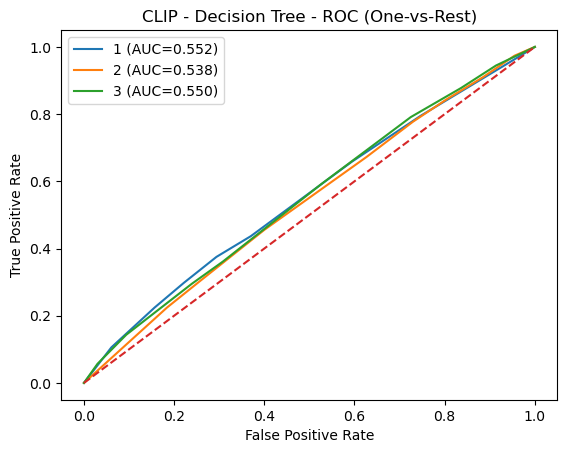

In [29]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = dt_clip.classes_
y_test_bin = label_binarize(y_clip_test, classes=classes)
y_score = dt_clip.predict_proba(X_clip_test)

plt.figure()
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("CLIP - Decision Tree - ROC (One-vs-Rest)")
plt.legend()
plt.show()

### Pixel

#### Training model and Tuning the hyperparameters

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_pixel = pd.read_csv(pixel_csv)

In [5]:
X_pixel = df_pixel.copy().drop("Choice", axis=1)
y_pixel = df_pixel["Choice"].astype(str)

In [9]:
X_pixel_train, X_pixel_test, y_pixel_train, y_pixel_test = train_test_split(X_pixel, y_pixel, test_size=0.2, random_state=0)

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [20, 40, 60],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [1, 2, 3],
    "max_features": ["sqrt", "log2"],
    "ccp_alpha": [1e-4, 1e-3, 1e-2],
}

gs_pixel = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring="accuracy",
    cv=2,
    verbose=1, # basic output-1; detailed output-2
    return_train_score=True
)

gs_pixel.fit(X_pixel_train, y_pixel_train)

best_model = gs_pixel.best_estimator_
test_acc = best_model.score(X_pixel_test, y_pixel_test)

print("Best CV score (train CV):", gs_pixel.best_score_)
print("Test accuracy:", test_acc)

Fitting 2 folds for each of 324 candidates, totalling 648 fits
Best CV score (train CV): 0.33947499999999997
Test accuracy: 0.3321


In [51]:
gs_pixel.best_estimator_

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",'sqrt'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

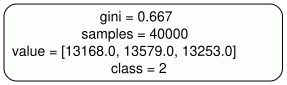

In [52]:
from sklearn import tree
import graphviz

dt_pixel = gs_pixel.best_estimator_

feature_names = list(X_pixel.columns)
target_names = [str(c) for c in dt_pixel.classes_]  # class labels as strings

dot_data = tree.export_graphviz(
    dt_pixel,
    out_file=None,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    special_characters=True,
)

graph = graphviz.Source(dot_data)
graph

In [53]:
# check and interpret feature importance
dt_pixel = gs_pixel.best_estimator_

importances = dt_pixel.feature_importances_
feat_names = X_pixel.columns if hasattr(X_pixel, "columns") else [f"f{i}" for i in range(X_pixel.shape[1])]

fi = (pd.DataFrame({"feature": feat_names, "importance": importances})
        .sort_values("importance", ascending=False))

print("Non-zero features used:", (fi["importance"] > 0).sum())
fi.head(4)

Non-zero features used: 0


,feature,importance
0,D_0_1,0.0
1,D_0_2,0.0
2,D_0_3,0.0
3,D_1_1,0.0


#### Error Analysis

##### Confusion Matrix
Overall, the model is more likely to predict the label as "2"

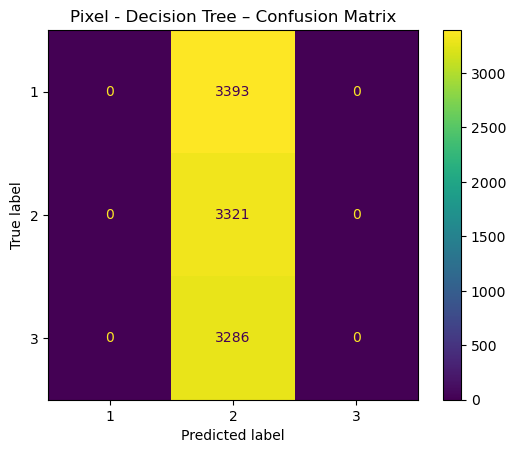

In [54]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

# predictions
y_pred = dt_pixel.predict(X_pixel_test)

# confusion matrix
cm = confusion_matrix(y_pixel_test, y_pred, labels=dt_pixel.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dt_pixel.classes_)
disp.plot(values_format="d")
plt.title("Pixel - Decision Tree – Confusion Matrix")
plt.show()

In [55]:
import numpy as np

print(classification_report(y_pixel_test, y_pred, zero_division=np.nan))

              precision    recall  f1-score   support

           1        nan      0.00      0.00      3393
           2       0.33      1.00      0.50      3321
           3        nan      0.00      0.00      3286

    accuracy                           0.33     10000
   macro avg       0.33      0.33      0.17     10000
weighted avg       0.33      0.33      0.17     10000



##### ROC
This Decision Tree model's performance is around the random level

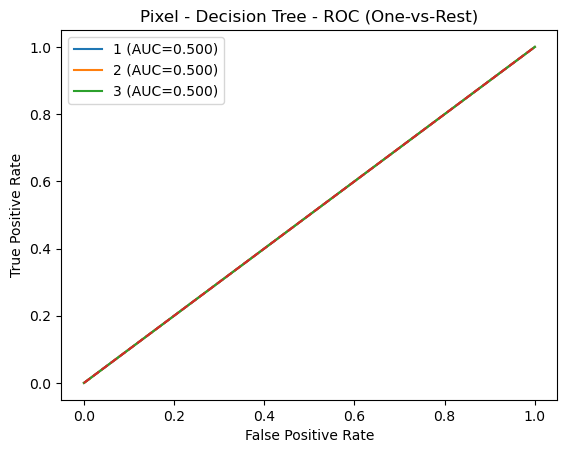

In [28]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = dt_pixel.classes_
y_test_bin = label_binarize(y_pixel_test, classes=classes)
y_score = dt_pixel.predict_proba(X_pixel_test)

plt.figure()
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Pixel - Decision Tree - ROC (One-vs-Rest)")
plt.legend()
plt.show()

## Using Random Forest
The Decision Tree model's performance for Pixel_Dataset is just around the random level, so I further run the Random Forest model for this dataset.

#### Training model and Tuning the hyperparameters

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

rf = RandomForestClassifier(
    random_state=0,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [300, 600, 1000],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10, 20, 50],
    "min_samples_leaf": [1, 2, 5, 10, 20],
    "max_features": ["sqrt", "log2", 0.2, 0.5],
    "bootstrap": [True],
    "max_samples": [0.6, 0.8, 1.0],
    "class_weight": [None, "balanced"],
}

rs = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,                
    scoring="accuracy",
    cv=2,
    verbose=2,
    random_state=42,
    return_train_score=True
)

rs.fit(X_pixel_train, y_pixel_train)

Fitting 2 folds for each of 20 candidates, totalling 40 fits
[CV] END bootstrap=True, class_weight=None, max_depth=None, max_features=0.5, max_samples=1.0, min_samples_leaf=5, min_samples_split=5, n_estimators=1000; total time=13.9min
[CV] END bootstrap=True, class_weight=None, max_depth=None, max_features=0.5, max_samples=1.0, min_samples_leaf=5, min_samples_split=5, n_estimators=1000; total time=13.7min
[CV] END bootstrap=True, class_weight=balanced, max_depth=10, max_features=0.5, max_samples=1.0, min_samples_leaf=20, min_samples_split=5, n_estimators=1000; total time= 9.7min
[CV] END bootstrap=True, class_weight=balanced, max_depth=10, max_features=0.5, max_samples=1.0, min_samples_leaf=20, min_samples_split=5, n_estimators=1000; total time= 9.7min
[CV] END bootstrap=True, class_weight=balanced, max_depth=10, max_features=0.5, max_samples=0.6, min_samples_leaf=10, min_samples_split=10, n_estimators=300; total time= 2.3min
[CV] END bootstrap=True, class_weight=balanced, max_depth=10

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True], 'class_weight': [None, 'balanced'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [11]:
rs

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True], 'class_weight': [None, 'balanced'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used he

In [12]:
best_model = rs.best_estimator_
test_acc = best_model.score(X_pixel_test, y_pixel_test)

print("Best CV score (train CV):", rs.best_score_)
print("Test accuracy:", test_acc)

Best CV score (train CV): 0.355825
Test accuracy: 0.3618


In [17]:
from sklearn import tree
import graphviz

tree_sample = best_model[0]
feature_names = list(X_pixel.columns)
target_names = [str(c) for c in tree_sample.classes_]  # class labels as strings

dot_data = tree.export_graphviz(
    tree_sample,
    out_file=None,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    special_characters=True,
)

graph = graphviz.Source(dot_data)
graph

In [18]:
# check and interpret feature importance
importances = tree_sample .feature_importances_
feat_names = X_pixel.columns if hasattr(X_pixel, "columns") else [f"f{i}" for i in range(X_pixel.shape[1])]

fi = (pd.DataFrame({"feature": feat_names, "importance": importances})
        .sort_values("importance", ascending=False))

print("Non-zero features used:", (fi["importance"] > 0).sum())
fi.head(10)

Non-zero features used: 515


,feature,importance
1194,D_398_1,0.008354
1507,D_502_2,0.006141
680,D_226_3,0.005780
1087,D_362_2,0.004955
421,D_140_2,0.004848
1098,D_366_1,0.004794
133,D_44_2,0.004792
1417,D_472_2,0.004771
719,D_239_3,0.004654
286,D_95_2,0.004467


#### Confusion Matrix

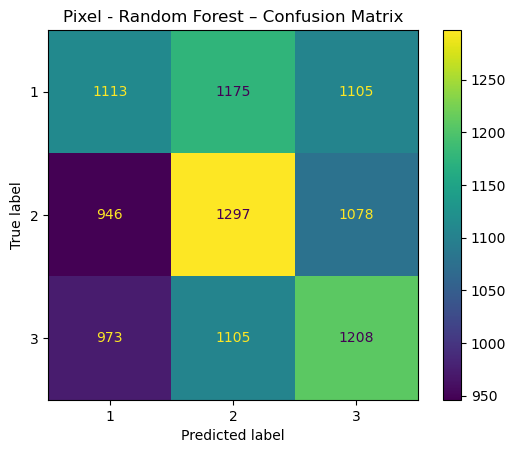

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report

# predictions
y_pred = best_model.predict(X_pixel_test)

# confusion matrix
cm = confusion_matrix(y_pixel_test, y_pred, labels=best_model.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(values_format="d")
plt.title("Pixel - Random Forest – Confusion Matrix")
plt.show()

In [14]:
print(classification_report(y_pixel_test, y_pred,zero_division=np.nan))

              precision    recall  f1-score   support

           1       0.37      0.33      0.35      3393
           2       0.36      0.39      0.38      3321
           3       0.36      0.37      0.36      3286

    accuracy                           0.36     10000
   macro avg       0.36      0.36      0.36     10000
weighted avg       0.36      0.36      0.36     10000



#### ROC
This Random Forest model's performance is slightly above the random level

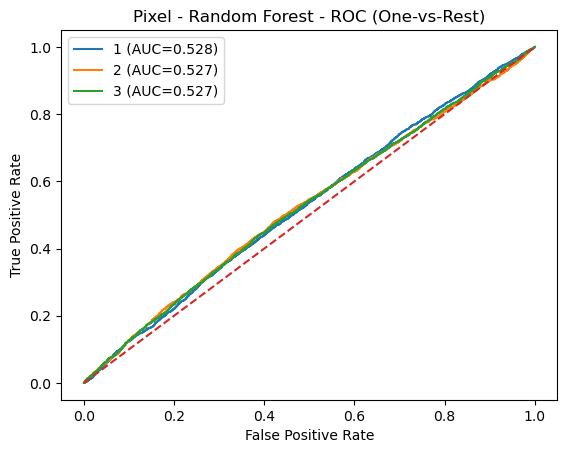

In [15]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

classes = best_model.classes_
y_test_bin = label_binarize(y_pixel_test, classes=classes)
y_score = best_model.predict_proba(X_pixel_test)

plt.figure()
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Pixel - Random Forest - ROC (One-vs-Rest)")
plt.legend()
plt.show()

## Evaluation of the DT Model
- Conclusions driven from the Decision Tree model: Overall, based on Decision Tree model, CLIP behaves better than Pixel, which aligns with previous hypothesis. But overal the test accuracy is not significantly above the random level. So maybe the Decision Tree model is not suitable for this task:
    - The test accuracy for CLIP (DT): 0.3704
    - The test accuracy for Pixel (DT): 0.3321
    - The test accuracy for Pixel (RF): 0.3618
- Pros
    - Explainable: could directly see important features, and how the decision is made.
- Cons
    - Can't take a lot of features into consideration: especially when the max_depth is little, among 512*3 features, only 8 features for CLIP. 
- Improvement:
    - Using random forest model: Based on current test, using random forest model could make use of more features(515 features), and perform better.

## Using Linear Model - Logistic Regression


Based on the Logistic Regression model, CLIP substantially outperforms Pixel, providing the strongest alignment with the study’s hypothesis that semantic representations better explain human odd-one-out judgments than low-level perceptual features:

- The test accuracy for CLIP (Logistic Regression): 0.4463
- The test accuracy for Pixel (Logistic Regression): 0.3399

Compared to tree-based models, Logistic Regression achieves the highest performance when combined with CLIP embeddings, indicating that the semantic information encoded in CLIP is linearly accessible and well aligned with human similarity judgments.

In contrast, the Logistic Regression model trained on pixel-based representations remains close to the random baseline, suggesting that increasing model simplicity or complexity does not compensate for the lack of semantic structure in pixel-level features.

Overall, these results indicate that representation quality plays a more critical role than model complexity, and that a linear classifier is sufficient to extract meaningful semantic structure from CLIP embeddings in this task.


In [2]:
import numpy as np
import pandas as pd

from collections import Counter

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, PredefinedSplit


In [4]:
def load_xy(csv_path: str):
    df = pd.read_csv(csv_path)
    if "Choice" in df.columns:
        y = df["Choice"].to_numpy()
        X = df.drop(columns=["Choice"]).to_numpy()
        feature_names = [c for c in df.columns if c != "Choice"]
    else:
        y = df.iloc[:, -1].to_numpy()
        X = df.iloc[:, :-1].to_numpy()
        feature_names = list(df.columns[:-1])

    try:
        y = y.astype(int)
    except Exception:
        pass

    return X, y, feature_names, df


### GridSearchCV

In [15]:

def gridsearch_with_predefined_valid(
    X_train, y_train,
    X_valid, y_valid,
    penalty_list=("l2", "l1"),
    C_list=(0.01, 0.1, 1, 10, 100),
    scoring="balanced_accuracy"
):
    # concat train + valid
    X_all = np.vstack([X_train, X_valid])
    y_all = np.concatenate([y_train, y_valid])

    # PredefinedSplit: -1 = always train, 0 = validation fold
    test_fold = np.concatenate([
        -1 * np.ones(len(y_train), dtype=int),
         0 * np.ones(len(y_valid), dtype=int),
    ])
    ps = PredefinedSplit(test_fold=test_fold)

    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="saga",      # supports both L1 and L2
            max_iter=4000,
            random_state=0
        ))
    ])

    param_grid = {
        "clf__penalty": list(penalty_list),
        "clf__C": list(C_list)
    }

    gs = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring=scoring,
        cv=ps,          
        n_jobs=-1,
        refit=True
    )

    gs.fit(X_all, y_all)
    return gs


def eval_on_test(best_estimator, X_test, y_test, name="MODEL"):
    pred = best_estimator.predict(X_test)
    print(f"\n=== {name} TEST ===")
    print("Acc:", accuracy_score(y_test, pred))
    print("Balanced Acc:", balanced_accuracy_score(y_test, pred))
    print("\nReport:\n", classification_report(y_test, pred, digits=4))
    print("Confusion:\n", confusion_matrix(y_test, pred))

### CLIP

In [16]:
# paths
CLIP_TRAIN = "clip_train.csv"
CLIP_VALID = "clip_valid.csv"
CLIP_TEST  = "clip_test.csv"

Xc_train, yc_train, clip_feat_names, _ = load_xy(CLIP_TRAIN)
Xc_valid, yc_valid, _, _ = load_xy(CLIP_VALID)
Xc_test,  yc_test,  _, _ = load_xy(CLIP_TEST)

print("CLIP train/valid/test:", Xc_train.shape, Xc_valid.shape, Xc_test.shape)
print("CLIP train label dist:", Counter(yc_train))

gs_clip = gridsearch_with_predefined_valid(Xc_train, yc_train, Xc_valid, yc_valid)

print("\n CLIP GridSearchCV via PredefinedSplit")
print("Best params:", gs_clip.best_params_)
print("Best valid score:", gs_clip.best_score_)

eval_on_test(gs_clip.best_estimator_, Xc_test, yc_test, name="CLIP")


CLIP train/valid/test: (34999, 512) (7501, 512) (7500, 512)
CLIP train label dist: Counter({2: 11806, 3: 11615, 1: 11578})

 CLIP GridSearchCV via PredefinedSplit
Best params: {'clf__C': 0.01, 'clf__penalty': 'l1'}
Best valid score: 0.4550207198082002

=== CLIP TEST ===
Acc: 0.4438666666666667
Balanced Acc: 0.44630711804224016

Report:
               precision    recall  f1-score   support

           1     0.4562    0.5404    0.4948      2489
           2     0.3925    0.2536    0.3081      2563
           3     0.4606    0.5449    0.4993      2448

    accuracy                         0.4439      7500
   macro avg     0.4365    0.4463    0.4340      7500
weighted avg     0.4359    0.4439    0.4324      7500

Confusion:
 [[1345  526  618]
 [ 969  650  944]
 [ 634  480 1334]]


### Pixel

In [17]:
PIXEL_TRAIN = "pixel_train.csv"
PIXEL_VALID = "pixel_valid.csv"
PIXEL_TEST  = "pixel_test.csv"

Xp_train, yp_train, pixel_feat_names, _ = load_xy(PIXEL_TRAIN)
Xp_valid, yp_valid, _, _ = load_xy(PIXEL_VALID)
Xp_test,  yp_test,  _, _ = load_xy(PIXEL_TEST)

print("PIXEL train/valid/test:", Xp_train.shape, Xp_valid.shape, Xp_test.shape)
print("PIXEL train label dist:", Counter(yp_train))

gs_pixel = gridsearch_with_predefined_valid(Xp_train, yp_train, Xp_valid, yp_valid)

print("\nPIXEL VALID GridSearchCV")
print("Best params:", gs_pixel.best_params_)
print("Best valid score:", gs_pixel.best_score_)

eval_on_test(gs_pixel.best_estimator_, Xp_test, yp_test, name="PIXEL")


PIXEL train/valid/test: (34999, 512) (7501, 512) (7500, 512)
PIXEL train label dist: Counter({2: 11806, 3: 11615, 1: 11578})

PIXEL VALID GridSearchCV
Best params: {'clf__C': 0.01, 'clf__penalty': 'l1'}
Best valid score: 0.33589832325768915

=== PIXEL TEST ===
Acc: 0.34
Balanced Acc: 0.3398937947715825

Report:
               precision    recall  f1-score   support

           1     0.3428    0.3387    0.3407      2489
           2     0.3422    0.3472    0.3447      2563
           3     0.3348    0.3337    0.3343      2448

    accuracy                         0.3400      7500
   macro avg     0.3399    0.3399    0.3399      7500
weighted avg     0.3400    0.3400    0.3400      7500

Confusion:
 [[843 881 765]
 [815 890 858]
 [801 830 817]]


In [21]:

# CLIP how many dimensions are left
best_model = gs_clip.best_estimator_
clf = best_model.named_steps["clf"]

coef = clf.coef_   
nonzero_mask = np.any(coef != 0, axis=0)

num_nonzero_dims = np.sum(nonzero_mask)
num_total_dims = coef.shape[1]

num_nonzero_dims, num_total_dims


(378, 512)

In [22]:

#PIXEL how many dimensions are left

best_model = gs_pixel.best_estimator_
clf = best_model.named_steps["clf"]

coef = clf.coef_   
nonzero_mask = np.any(coef != 0, axis=0)

num_nonzero_dims = np.sum(nonzero_mask)
num_total_dims = coef.shape[1]

num_nonzero_dims, num_total_dims


(304, 512)

## Error Analysis

#### ROC

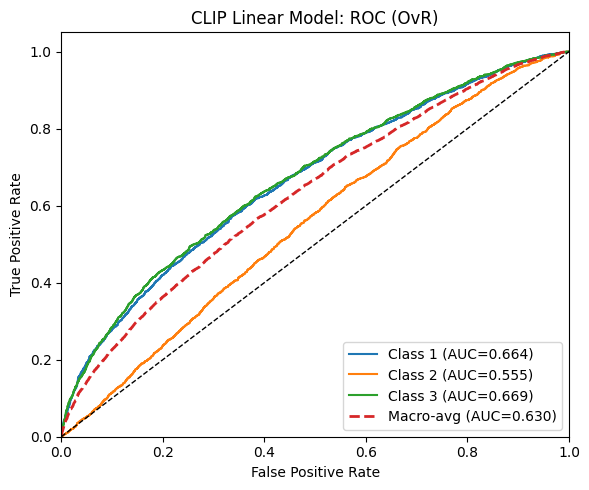

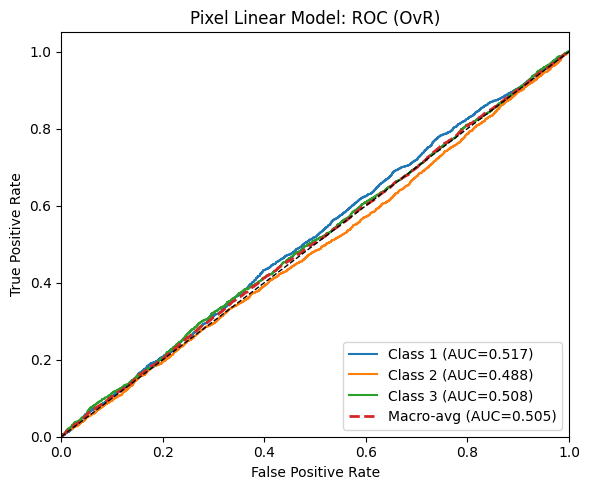

Macro-AUC (CLIP): 0.6296
Macro-AUC (Pixel): 0.5046


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def plot_multiclass_roc(model, X_test, y_test, title="ROC (OvR)"):
    """
    Multiclass ROC using One-vs-Rest (OvR).
    Assumes y_test is {1,2,3} or {0,1,2}. Converts to 0-based internally.
    """
    y = np.array(y_test).astype(int)
    if y.min() == 1 and y.max() == 3:
        y = y - 1  # convert {1,2,3} -> {0,1,2}

    classes = [0, 1, 2]
    y_bin = label_binarize(y, classes=classes)

    # predicted probabilities (N,3)
    y_score = model.predict_proba(X_test)

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(classes)):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # AUC
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(len(classes))]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(len(classes)):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= len(classes)
    macro_auc = auc(all_fpr, mean_tpr)

    # plot
    plt.figure(figsize=(6, 5))
    for i in range(len(classes)):
        plt.plot(fpr[i], tpr[i], label=f"Class {i+1} (AUC={roc_auc[i]:.3f})")  # +1 to match Choice=1/2/3
    plt.plot(all_fpr, mean_tpr, linestyle="--", linewidth=2, label=f"Macro-avg (AUC={macro_auc:.3f})")
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    return macro_auc


clip_model = gs_clip.best_estimator_
pixel_model = gs_pixel.best_estimator_

clip_macro_auc = plot_multiclass_roc(clip_model, Xc_test, yc_test, title="CLIP Linear Model: ROC (OvR)")
pixel_macro_auc = plot_multiclass_roc(pixel_model, Xp_test, yp_test, title="Pixel Linear Model: ROC (OvR)")

print("Macro-AUC (CLIP):", round(clip_macro_auc, 4))
print("Macro-AUC (Pixel):", round(pixel_macro_auc, 4))


#### Confusion Matrix

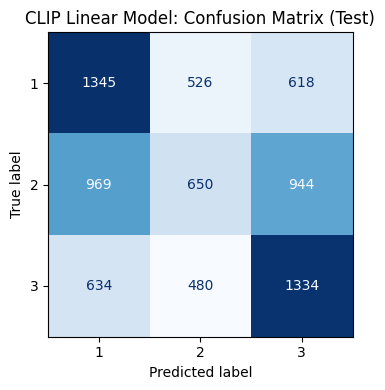

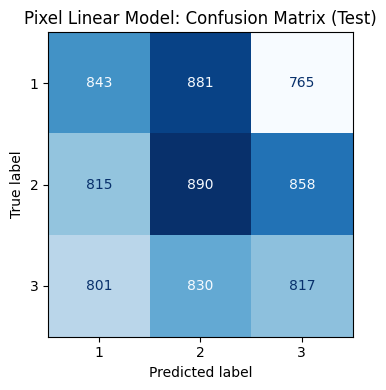


=== CLIP Linear Model: Non-zero Features (L1) ===
Non-zero features kept: 378 / 512  (73.83%)

Top-20 features by mean |weight| (across classes):
  D_20: 0.071125
  D_176: 0.053965
  D_104: 0.041040
  D_296: 0.040394
  D_221: 0.037271
  D_367: 0.037170
  D_357: 0.033986
  D_218: 0.033392
  D_398: 0.032417
  D_378: 0.030281
  D_39: 0.030145
  D_360: 0.029759
  D_402: 0.029745
  D_233: 0.028599
  D_8: 0.027862
  D_305: 0.027100
  D_106: 0.026555
  D_98: 0.023253
  D_211: 0.022401
  D_432: 0.022169

=== Pixel Linear Model: Non-zero Features (L1) ===
Non-zero features kept: 304 / 512  (59.38%)

Top-20 features by mean |weight| (across classes):
  D_3: 0.028496
  D_13: 0.013998
  D_9: 0.009970
  D_25: 0.008801
  D_385: 0.007936
  D_477: 0.007010
  D_327: 0.006853
  D_267: 0.006708
  D_257: 0.006335
  D_128: 0.006295
  D_236: 0.006142
  D_83: 0.006139
  D_117: 0.006096
  D_326: 0.005984
  D_306: 0.005963
  D_81: 0.005945
  D_303: 0.005858
  D_400: 0.005786
  D_250: 0.005522
  D_309: 0.00537

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix plots

def plot_cm(model, X, y, title):
    y_pred = model.predict(X)
    labels = np.unique(np.concatenate([np.unique(y), np.unique(y_pred)]))
    cm = confusion_matrix(y, y_pred, labels=labels)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()
    return cm

cm_clip  = plot_cm(gs_clip.best_estimator_,  Xc_test, yc_test, "CLIP Linear Model: Confusion Matrix (Test)")
cm_pixel = plot_cm(gs_pixel.best_estimator_, Xp_test, yp_test, "Pixel Linear Model: Confusion Matrix (Test)")



def nonzero_feature_report(pipeline_model, feature_names=None, model_name="MODEL", top_k=20):
    clf = pipeline_model.named_steps["clf"]
    coef = clf.coef_  

    kept_mask = np.any(coef != 0, axis=0)
    n_kept = int(kept_mask.sum())
    n_total = coef.shape[1]

    print(f"\n=== {model_name}: Non-zero Features (L1) ===")
    print(f"Non-zero features kept: {n_kept} / {n_total}  ({100.0*n_kept/n_total:.2f}%)")

    if feature_names is not None:
        mean_abs_w = np.mean(np.abs(coef), axis=0)
        top_idx = np.argsort(mean_abs_w)[::-1][:top_k]

        print(f"\nTop-{top_k} features by mean |weight| (across classes):")
        for j in top_idx:
            fname = feature_names[j] if j < len(feature_names) else f"f{j}"
            print(f"  {fname}: {mean_abs_w[j]:.6f}")



    return n_kept, n_total, kept_mask

clip_kept = nonzero_feature_report(
    gs_clip.best_estimator_,
    feature_names=clip_feat_names,
    model_name="CLIP Linear Model",
    top_k=20
)

pixel_kept = nonzero_feature_report(
    gs_pixel.best_estimator_,
    feature_names=pixel_feat_names,
    model_name="Pixel Linear Model",
    top_k=20
)


## Evaluation of the Linear Model
- Conclusions driven from the Logistic Regression model: With the Logistic Regression model, CLIP behaves substantially better than Pixel, providing the strongest support for the hypothesis that semantic representations align more closely with human odd-one-out judgments. Unlike tree-based models, the linear model achieves clearly above-random performance when combined with CLIP embeddings:
    - The test accuracy for CLIP (Logistic Regression): 0.4463
    - The test accuracy for Pixel (Logistic Regression): 0.3399
- Pros
    - Efficient and stable: trains quickly and scales well to large datasets.
    - Fair comparison across representations: the same linear decision boundary is applied to both CLIP and Pixel features.
- Cons
    - Limited modeling capacity: cannot capture complex nonlinear interactions among features.



## Project Summary and Implications


### Model Comparison
Two main classes of models were evaluated: tree-based models (Decision Tree and Random Forest) and a linear model (Logistic Regression).

Tree-based models showed that CLIP representations consistently performed better than pixel-based representations. However, overall performance remained only slightly above chance. 

Decision Trees were limited by shallow depth and high dimensionality. Random Forests improved performance modestly at the cost of substantially increased training time. These results suggest that increased model complexity alone does not compensate for weak representations.

In contrast, Logistic Regression achieved a stronger performance when combined with CLIP embeddings. The CLIP + Logistic Regression model significantly outperformed all pixel-based models and all tree-based models, indicating that semantic information relevant to human similarity judgments is already linearly accessible in the CLIP representation. Pixel-based Logistic Regression remained near chance, further reinforcing the limitation of purely perceptual features.


### Implications
These findings suggest that human similarity judgments rely more heavily on semantic structure than on raw perceptual similarity. The success of linear models with CLIP embeddings indicates that high-level semantic information is explicitly encoded in the representation and aligns well with human conceptual organization. In contrast, pixel-based model performance highlights the insufficiency of low-level visual information alone for modeling human similarity behavior.

Overall, this project demonstrates that simple, interpretable models can effectively reveal meaningful alignment between machine representations and human cognition when the underlying representation is strong.


## Contribution of Each Group Member

- Tangxiaoxue Zhang: Literature Review, Exploratory Data Analysis, Semantic and Pixel Data Formulation, Decision Tree (Fit, Analysis, and Evaluation), Slides
- Victoria Wen: Literature Review, Logistic Regression (Fit, Analysis, and Evaluation), Conclusion and Implication, Slides, Presentation Video Editing